## 铰接模型的视线
基于模型“ RODM_Hige_study_plan_a_2.ipynb ” 在多铰接实现中存在的结果与论文结果拟合不好的问题，猜测是由于铰接连接点处为受力点，需要设置明确的节点。
### 本程序建立模型方案基本如下：
1、导入子模块刚度、质量矩阵。
2、直接对子模块刚度及质量矩阵进行降维，扩大控制点的数量。（降维后水动力数据与结构数据维度不统一）
3、在边缘节点上建立铰接模型、加入铰接的刚度矩阵
4、将水动力系数施加到对应位置的主控制点上，构建运动方程

In [61]:
#import packages
import time
import numpy as np
import capytaine as cpt
import scipy
from capytaine.io.mesh_writers import write_STL
import matplotlib.pyplot as plt
from scipy.linalg import block_diag
from scipy.linalg import eigh
import vtk
import logging
import xarray as xr
from capytaine.io.xarray import merge_complex_values
from capytaine.post_pro import rao
logging.basicConfig(level=logging.INFO, format='%(levelname)-8s: %(message)s')
# user defined functions
import DM_ShowNodes as DMshow
import DM_Reading as dm_r
import DM_Assemble as DM_A
import SEREP as SEREP
import DM_Method as DM_M
import pandas as pd

### 为了方便调整参数形成的完整程序

In [62]:
file_m = r'E:\phd\Code\DM-FEM2D\StructureData\Yoon_hinge\Job_hinge_study_100_60_YoonModel_MASS1.mtx'
file_k = r'E:\phd\Code\DM-FEM2D\StructureData\Yoon_hinge\Job_hinge_study_100_60_YoonModel_STIF1.mtx'
hydro_file = r'E:\phd\Code\DM-FEM2D\HydrodynamicData\Yoon_hinge\DM10_direction0_slender_180.nc'  # 水动力数据文件路径
num_nodes = 273
modules = 10
# 获取刚度矩阵和质量矩阵
m = dm_r.get_stiffness_matrix(file_m)
k = dm_r.get_stiffness_matrix(file_k)

master_nodes = sorted([127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147]) # 21个主节点


# 使用 SEREP 或 static_condensation 进行降阶
fem_m_reduced = SEREP.reduce_dofs(m, num_nodes, [5])
fem_siffness_reduced = SEREP.reduce_dofs(k, num_nodes, [5])

# 获取主自由度和从自由度
MasterDofs, SlaveDofs = SEREP.separate_dofs(num_nodes, master_nodes)

# MR, KR, T = SEREP.SEREP(fem_m_reduced, fem_siffness_reduced, SlaveDofs, master_nodes)

MR, KR, T = SEREP.static_condensation(fem_siffness_reduced, fem_m_reduced, MasterDofs, SlaveDofs)

In [63]:
import numpy as np
import scipy.linalg as la

def compare_matrices(M, K, MR, KR, num_modes=None):
    # Step 1: Eigenvalue comparison for original model
    eig_vals_original, _ = la.eigh(K, M)  # Original model eigenvalues only

    # Step 2: Eigenvalue comparison for reduced model
    eig_vals_reduced, _ = la.eigh(KR, MR)  # Reduced model eigenvalues only
    
    # Determine the number of modes to compare (default is the number of reduced modes)
    if num_modes is None:
        num_modes = min(len(eig_vals_original), len(eig_vals_reduced))
    
    # Truncate both models to the first num_modes for fair comparison
    eig_vals_original = eig_vals_original[:num_modes]
    eig_vals_reduced = eig_vals_reduced[:num_modes]

    # Step 3: Relative error in eigenvalues
    relative_eigval_error = np.abs(eig_vals_original - eig_vals_reduced) / np.abs(eig_vals_original)
    
    # Step 4: Frobenius norm comparison (truncate the reduced matrices to match the original)
    frobenius_mass_error = np.linalg.norm(M[:MR.shape[0], :MR.shape[1]] - MR, 'fro') / np.linalg.norm(M, 'fro')
    frobenius_stiffness_error = np.linalg.norm(K[:KR.shape[0], :KR.shape[1]] - KR, 'fro') / np.linalg.norm(K, 'fro')
    
    # Step 5: Spectral norm comparison (truncate the reduced matrices to match the original)
    spectral_mass_error = np.linalg.norm(M[:MR.shape[0], :MR.shape[1]] - MR, 2) / np.linalg.norm(M, 2)
    spectral_stiffness_error = np.linalg.norm(K[:KR.shape[0], :KR.shape[1]] - KR, 2) / np.linalg.norm(K, 2)
    
    # Results
    print("Eigenvalue Relative Error:", relative_eigval_error)
    print(f"Frobenius Norm Error (Mass Matrix): {frobenius_mass_error:.6f}")
    print(f"Frobenius Norm Error (Stiffness Matrix): {frobenius_stiffness_error:.6f}")
    print(f"Spectral Norm Error (Mass Matrix): {spectral_mass_error:.6f}")
    print(f"Spectral Norm Error (Stiffness Matrix): {spectral_stiffness_error:.6f}")
    
    return {
        "relative_eigenvalue_error": relative_eigval_error,
        "frobenius_mass_error": frobenius_mass_error,
        "frobenius_stiffness_error": frobenius_stiffness_error,
        "spectral_mass_error": spectral_mass_error,
        "spectral_stiffness_error": spectral_stiffness_error
    }

# Example usage: Replace with your actual M, K, MR, and KR matrices
M = fem_m_reduced
K = fem_siffness_reduced
MR = MR
KR = KR

result = compare_matrices(M, K, MR, KR)


Eigenvalue Relative Error: [6.72636750e-01 5.47840299e-01 8.43857581e-01 7.74182700e-01
 7.88612239e-01 8.25711093e-02 1.98891317e-01 3.74163053e-01
 4.68334229e-01 4.06494137e-01 5.21844995e+00 3.81111717e+00
 6.14563747e+00 5.65573862e+00 6.80526399e+00 5.21238435e+00
 6.30017306e+00 6.70884821e+00 1.12849332e+01 1.00690634e+01
 1.17102501e+01 1.41994157e+01 1.44067095e+01 2.18481645e+01
 1.78582324e+01 1.88731038e+01 1.77573332e+01 2.17377315e+01
 2.72920718e+01 2.50547092e+01 2.65832285e+01 2.65777073e+01
 3.26714747e+01 3.04627008e+01 3.08710236e+01 3.35651557e+01
 3.30916478e+01 3.51158656e+01 3.76498751e+01 3.81085545e+01
 3.68437216e+01 3.73777366e+01 3.66998323e+01 3.56079368e+01
 3.60835565e+01 3.48818849e+01 3.38303989e+01 3.33365486e+01
 2.79193522e+01 2.77331311e+01 2.72463941e+01 2.90009164e+01
 3.30728998e+01 3.41885343e+01 3.44287931e+01 3.55063423e+01
 3.55100181e+01 3.49176506e+01 3.54301392e+01 3.47850058e+01
 3.35209325e+01 3.41605359e+01 3.32885242e+01 3.03923598e+

In [64]:
# 将单个结构的刚度矩阵拼接为大的矩阵
def create_block_matrix(matrix, n):
    """
    创建一个 n 个结构的块对角矩阵。
    matrix 是单个结构的刚度或质量矩阵，n 是结构的数量。
    """
    zero_matrix = np.zeros_like(matrix)
    blocks = []

    for i in range(n):
        row_blocks = [zero_matrix] * n
        row_blocks[i] = matrix
        blocks.append(row_blocks)

    big_matrix = np.block(blocks)
    return big_matrix

n = 3
# 使用相同的函数生成刚度矩阵和质量矩阵的块对角矩阵
fem_k = create_block_matrix(KR, n)
fem_m = create_block_matrix(MR, n)

hinges = [([21],[22]),([42],[43])]#[([21],[22]),([42],[43])]

k_hinge = 1e12
def apply_hinge_joints(fem_kiffness, k_hinge, hinges):
    """
    将铰链关节刚度矩阵应用到全局刚度矩阵中，适用于多个模块之间的铰接。

    参数:
    fem_kiffness (numpy.ndarray): 全局刚度矩阵。
    k_hinge (float): 铰链关节的刚度。
    hinges (list of tuple): 每个铰接节点对的列表，每个元组包含两个节点编号列表。

    返回:
    numpy.ndarray: 更新后的全局刚度矩阵。
    """
    # 定义铰链关节的刚度矩阵
    KC = np.diag([k_hinge, k_hinge, k_hinge, k_hinge, 1, k_hinge])
    negative_KC = -KC

    # 处理所有铰接
    for nodes_k1, nodes_k2 in hinges:
        for node1, node2 in zip(nodes_k1, nodes_k2):
            # 计算在大矩阵中的索引位置
            index1 = (node1 - 1) * 6  # K_1 节点自由度起始位置
            index2 = (node2 - 1) * 6  # K_2 节点自由度起始位置

            # 在节点自身设置 KC
            fem_kiffness[index1:index1+6, index1:index1+6] += KC
            fem_kiffness[index2:index2+6, index2:index2+6] += KC

            # 设置两节点间的相互作用 -KC
            fem_kiffness[index1:index1+6, index2:index2+6] += negative_KC
            fem_kiffness[index2:index2+6, index1:index1+6] += negative_KC
    
    return fem_kiffness

fem_k_hinge = apply_hinge_joints(fem_k, k_hinge, hinges)

In [65]:
# 读取水动力数据
dataset = merge_complex_values(xr.open_dataset(hydro_file))
omega = dataset.omega.values
print(omega)

# Read and reduce hydrodynamic data for system matrices
inertia_matrix = SEREP.reduce_dofs(dataset['inertia_matrix'].values, modules, [5])
added_mass = SEREP.reduce_dofs(dataset['added_mass'][0].values, modules, [5])
radiation_damping = SEREP.reduce_dofs(dataset['radiation_damping'][0].values, modules, [5])
hydrostatic_stiffness = SEREP.reduce_dofs(dataset['hydrostatic_stiffness'].values, modules, [5])

F_w_hydro = dataset['Froude_Krylov_force'][0].values + dataset['diffraction_force'][0].values
F_w_hydro_redu = SEREP.reduce_force_matrix_dofs(F_w_hydro, modules, 5)[::-1].reshape(1, modules*5)

# Construct the combined matrices
M = added_mass  # Total mass fem_m inertia_matrix 
C = radiation_damping  # Damping
K = hydrostatic_stiffness  # Stiffness

num_nodes = 63
force_nodes = [4,10,16,23,29,35,41,48,54,60]  #[4,10,16,23,29,35,41,48,54,60] [6,16,27,37,48,58] 
# Insert matrices into the system
mass = DM_A.insert_matrix(num_nodes, M, force_nodes, dof_num=5)  #+ fem_m
damping = DM_A.insert_matrix(num_nodes, C, force_nodes, dof_num=5)
hy_stiffness = DM_A.insert_matrix(num_nodes, K, force_nodes, dof_num=5)

# Assemble the stiffness matrix
stiffness = fem_k_hinge + hy_stiffness

# Assemble the force matrix
K_F_w = DM_A.extend_force_matrix(F_w_hydro_redu, force_nodes, num_nodes, dof_num=5)

X = DM_A.solve_frequency_domain(mass+fem_m, damping, stiffness, K_F_w, omega)

[0.5851]


In [66]:
cond_K_ss = np.linalg.cond(fem_k_hinge)
print(f"Condition number of K_ss: {cond_K_ss}")


Condition number of K_ss: 5.387018945722856e+18


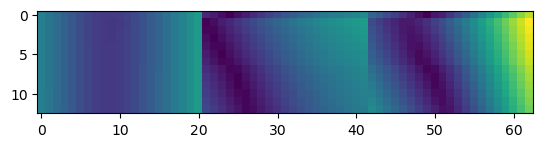

In [67]:
X_A  = X[0:105]
X_B  = X[105:210]
X_C  = X[210:315]
dis_a = T@X_A
dis_b = T@X_B
dis_c = T@X_C
heave_a = dis_a.reshape(13,21,5)[:,:,2]
heave_b = dis_b.reshape(13,21,5)[:,:,2]
heave_c = dis_c.reshape(13,21,5)[:,:,2]
disp = np.concatenate((heave_a,heave_b,heave_c),axis=1)
plt.imshow(abs(disp))

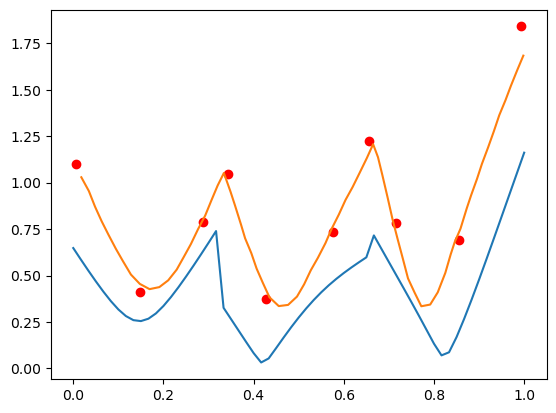

In [68]:
displacement = np.delete(disp[12,:], [20, 41], axis=0)
x = np.linspace(0, 1, 61)
plt.plot(x, abs(displacement))
df = pd.read_csv(r'E:\phd\Code\DM-FEM2D\FEM_Reduce\Hinge\Yoon_numerical_0_2.csv', header=None)
plt.plot(df.iloc[:, 0], df.iloc[:, 1], label='Yoon et al.2014')

df2 = pd.read_csv(r'E:\phd\Code\DM-FEM2D\FEM_Reduce\Hinge\Yoon_exp.csv', header=None)
plt.scatter(df2.iloc[:, 0], df2.iloc[:, 1], color='red', label='Yoon Exp')

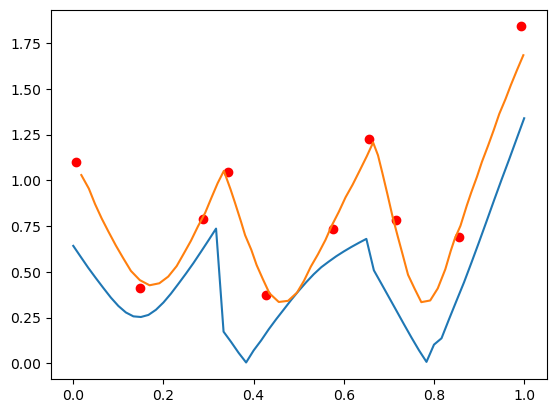

In [69]:
displacement_or = X.reshape(63,5)
displacement = np.delete(displacement_or, [20, 41], axis=0)
x = np.linspace(0, 1, 61)
plt.plot(x,np.abs(displacement[:,2]))
df = pd.read_csv(r'E:\phd\Code\DM-FEM2D\FEM_Reduce\Hinge\Yoon_numerical_0_2.csv', header=None)
plt.plot(df.iloc[:, 0], df.iloc[:, 1], label='Yoon et al.2014')

df2 = pd.read_csv(r'E:\phd\Code\DM-FEM2D\FEM_Reduce\Hinge\Yoon_exp.csv', header=None)
plt.scatter(df2.iloc[:, 0], df2.iloc[:, 1], color='red', label='Yoon Exp')